# PRÁCTICA FINAL:  IA Y CIBERSEGURIDAD

### ANÁLISIS Y MODELADO DE DATOS DE CIBERATAQUES MEDIANTE MACHINE LEARNING

En el presente trabajo se aborda un problema de **machine learning** aplicado a un conjunto de datos reales relacionados con incidentes de ciberseguridad.
El objetivo es aplicar las metodologías y buenas prácticas desarrolladas durante el curso, realizando un **análisis exploratorio de los datos**, su **preprocesamiento** y el posterior **modelado**.
El dataset contiene distintas variables relacionadas con incidentes de ciberseguridad, entre las cuales se identifica **"Action Taken"** como la **variable objetivo principal** sobre la que se centrará el presente trabajo, tal como establece la consigna.
Dado que se trata de la variable objetivo obligatoria de la práctica, todo el análisis exploratorio, el preprocesamiento y el modelado posterior estarán orientados a su predicción.
Al tratarse de datos reales, se requiere un análisis detallado y un proceso de limpieza y transformación adecuado, priorizando la correcta interpretación de los datos por sobre la complejidad de los modelos.
A lo largo del trabajo se seguirá un enfoque progresivo, comenzando por etapas básicas para luego avanzar hacia la construcción de un modelo de clasificación.
Como primer paso, se procederá a la carga de las librerías necesarias para el desarrollo del análisis.

#### CARGAMOS LAS BIBLIOTECAS BASICAS NECESARIAS

In [1]:
import pandas as pd
import numpy as np

### 1. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

#### INTRODUCCIÓN AL ANÁLISIS EXPLORATORIO DE DATOS (EDA)

En esta etapa se realiza un primer **análisis del dataset** con el objetivo de comprender su **estructura**, identificar las **variables disponibles** y detectar posibles **características relevantes**.

Para ello, se explorarán los datos mediante distintas **herramientas** que permitirán obtener una **visión general** antes de avanzar hacia etapas más complejas del proceso de **machine learning**.

#### CARGAMOS EL DATASET
Lo primero que haremos será importar el **conjunto de datos original** para realizar un análisis de nuestra información:

In [2]:
df = pd.read_csv('data/cybersecurity_attacks.csv')

#### VISTA INICIAL
Echamos un vistazo a las **primeras filas** de nuestros datos: 

In [3]:
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


#### ESTRUCTURA DEL DATASET
Revisamos las **columnas** y **tipos de datos** para entender la estructura:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

#### ESTADISTICAS
Descripción de básicas de nuestra información: 

In [5]:
df.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


#### VALORES ATIPICOS - OUTLIERS

En esta etapa se analiza la posible presencia de **valores atípicos (outliers)** dentro de las variables numéricas del dataset, ya que estos podrían influir en el rendimiento de los modelos de clasificación.

Se selecciona la variable **Packet Length** como ejemplo representativo por tratarse de una variable numérica continua y fácilmente interpretable dentro del contexto del problema. El objetivo es verificar si existen valores extremos que puedan requerir tratamiento previo al modelado.

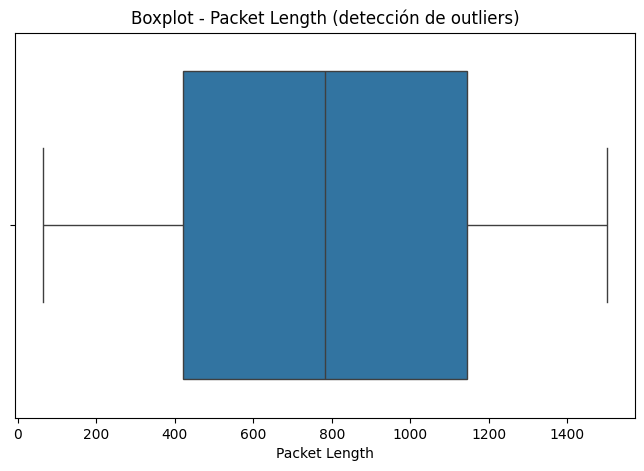

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Packet Length'])
plt.title("Boxplot - Packet Length (detección de outliers)")
plt.xlabel("Packet Length")
plt.show()

no se observan outliers extremos visibles en el boxplot

#### VALORES UNICOS
Contamos cuántos valores únicos hay en cada columna

In [7]:
df.nunique()

Timestamp                 39997
Source IP Address         40000
Destination IP Address    40000
Source Port               29761
Destination Port          29895
Protocol                      3
Packet Length              1437
Packet Type                   2
Traffic Type                  3
Payload Data              40000
Malware Indicators            1
Anomaly Scores             9826
Alerts/Warnings               1
Attack Type                   3
Attack Signature              2
Action Taken                  3
Severity Level                3
User Information          32389
Device Information        32104
Network Segment               3
Geo-location Data          8723
Proxy Information         20148
Firewall Logs                 1
IDS/IPS Alerts                1
Log Source                    2
dtype: int64

OUTLIERS - (VALORES ATIPICOS)

#### ANÁLISIS DE VARIABLE OBJETIVO

Se analiza la variable objetivo principal **"Action Taken"**, observando sus etiquetas y la distribución de sus valores con el objetivo de comprender mejor su comportamiento dentro del dataset.

In [8]:
df["Action Taken"].value_counts()

Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

#### DISTRIBUCIÓN DE LAS VARIABLES OBJETIVO

A continuación, se analiza la distribución de la variable objetivo **Action Taken**, con el fin de observar cómo se reparten sus clases dentro del dataset.

Este análisis resulta fundamental para identificar si existe **desbalance de clases**, ya que una distribución desigual podría afectar el entrenamiento y la evaluación de los modelos.

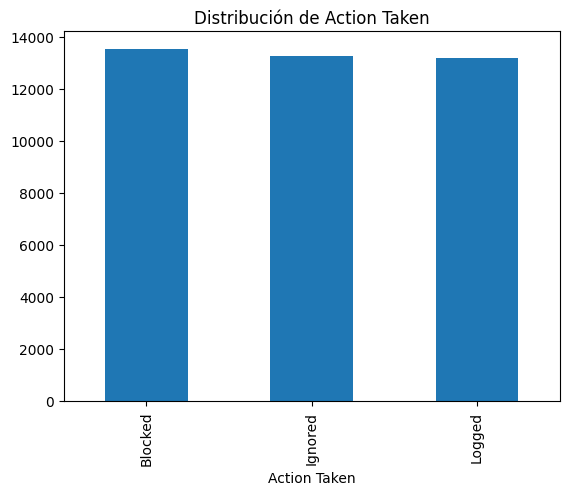

In [9]:
import matplotlib.pyplot as plt

df["Action Taken"].value_counts().plot(kind="bar")
plt.title("Distribución de Action Taken")
plt.show()

El gráfico confirma la distribución previamente observada, donde las clases se presentan de forma balanceada.

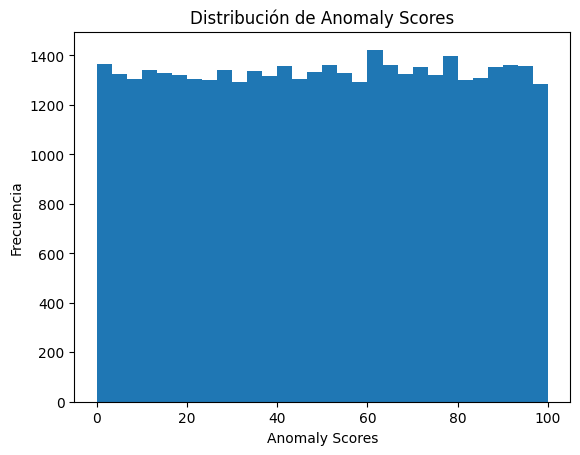

In [10]:
plt.hist(df["Anomaly Scores"], bins=30)
plt.title("Distribución de Anomaly Scores")
plt.xlabel("Anomaly Scores")
plt.ylabel("Frecuencia")
plt.show()

Se realiza un análisis de la distribución de la variable **Anomaly Scores** con el objetivo de comprender su comportamiento general dentro del conjunto de datos.

Este paso permite identificar la forma de la distribución, posibles concentraciones de valores y patrones que puedan resultar relevantes para el posterior modelado.

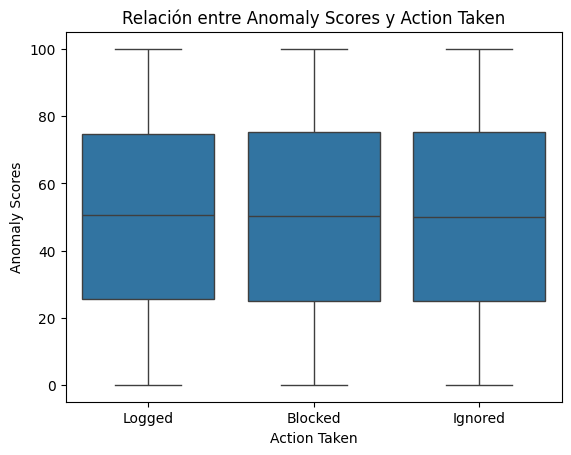

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Action Taken"], y=df["Anomaly Scores"])
plt.title("Relación entre Anomaly Scores y Action Taken")
plt.show()

Posteriormente, se analiza la relación entre la variable numérica **Anomaly Scores** y la variable objetivo **Action Taken**.

El propósito de este análisis es evaluar si los valores de esta variable presentan diferencias visibles entre las distintas clases, lo que permitiría inferir si puede aportar capacidad predictiva al modelo.

In [12]:
pd.crosstab(df["Protocol"], df["Action Taken"])

Action Taken,Blocked,Ignored,Logged
Protocol,,,
ICMP,4503,4492,4434
TCP,4487,4384,4401
UDP,4539,4400,4360


Se observa que la distribución de la variable "Protocol" es muy similar entre las distintas clases de "Action Taken", no presentando diferencias significativas. Esto indica que la variable no aporta información relevante para la discriminación entre clases, lo que puede limitar el rendimiento de los modelos de clasificación.

#### MATRIZ DE CORRELACION

Finalmente, se construye una **matriz de correlación** entre las variables numéricas con el objetivo de identificar posibles relaciones lineales entre ellas.

Este análisis permite detectar variables que puedan estar aportando información redundante al modelo y comprender mejor la estructura interna del dataset antes del preprocesamiento.

In [13]:
df.corr(numeric_only=True)

,Source Port,Destination Port,Packet Length,Anomaly Scores
Source Port,1.000000,-0.005216,0.003657,0.004826
Destination Port,-0.005216,1.000000,0.002581,-0.003616
Packet Length,0.003657,0.002581,1.000000,-0.003599
Anomaly Scores,0.004826,-0.003616,-0.003599,1.000000


En primer lugar, se calcula la **matriz de correlación** utilizando únicamente las **variables numéricas**. Esta matriz muestra el grado de **relación lineal** entre cada par de variables, con valores comprendidos entre **-1 y 1**.

Luego se representa la **matriz de correlación** mediante un **mapa de calor (heatmap)**, lo que facilita la interpretación visual de las relaciones entre variables. Los valores más cercanos a **1 o -1** indican correlaciones más fuertes, mientras que valores cercanos a **0** indican una relación débil o inexistente.

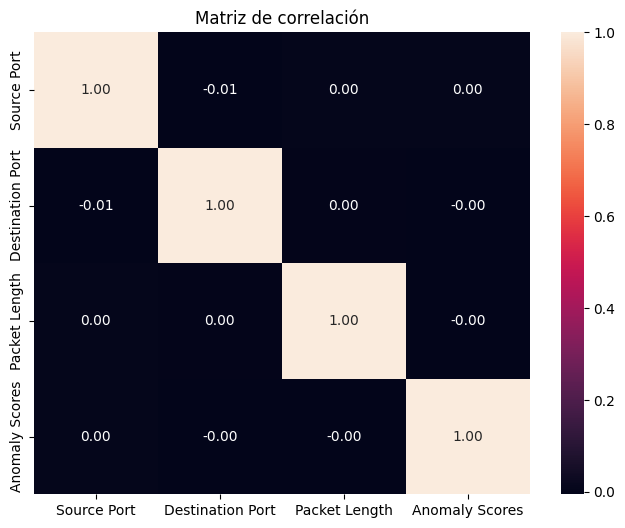

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

A partir del análisis realizado, no se observan correlaciones fuertes (cercanas a 1 o -1) entre las variables analizadas, lo que indica la ausencia de relaciones lineales significativas que puedan generar redundancia en la información.

##### ¿ A que nos referimos con, cercanas a 1 o -1?
Correlación = 1   → relación positiva perfecta (↑ una variable → ↑ la otra)  
Correlación = 0   → no existe relación  
Correlación = -1  → relación negativa perfecta (↑ una variable → ↓ la otra)

#### CONCLUSIÓN: EDA

A lo largo de esta etapa se realizó un **análisis exploratorio del dataset** con el objetivo de comprender su estructura, identificar variables relevantes y evaluar la calidad de la información disponible.
Se analizaron tanto las características generales de los datos como la distribución de la variable objetivo **"Action Taken"**, sobre la cual se centra el presente trabajo según lo establecido en la consigna.
El análisis permitió verificar que las clases de la variable objetivo se encuentran **balanceadas**, lo cual resulta favorable para el entrenamiento de modelos de clasificación. Asimismo, se analizaron las variables numéricas en busca de **valores atípicos (outliers)**, no observándose valores extremos significativos que requieran un tratamiento específico.
Por otro lado, se evaluó la **correlación entre variables numéricas**, no identificándose relaciones lineales fuertes que indiquen redundancia relevante entre ellas.
En consecuencia, se considera que el dataset se encuentra correctamente comprendido, habiéndose identificado las variables potencialmente útiles y aquellas que podrían requerir tratamiento o eliminación en etapas posteriores, quedando preparado para avanzar hacia la etapa de **preprocesamiento**.


## 2. PRE-PROCESAMIENTO DE DATOS

#### INTRODUCCIÓN AL PREPROCESAMIENTO

En esta etapa se prepararán los datos para su posterior uso en modelos de Machine Learning, realizando las transformaciones necesarias para su correcta interpretación.
En primer lugar, se llevará a cabo una limpieza del dataset, eliminando variables no relevantes y tratando posibles inconsistencias en los datos. Posteriormente, se aplicarán las transformaciones necesarias, como la codificación de variables categóricas.
Finalmente, se definirá la variable objetivo (y) y las variables predictoras (X), obteniendo así un dataset listo para el entrenamiento de modelos

#### REVISION DE VALORES NULOS - (NULLS)

Ahora procederemos a analizar la posible presencia de **valores nulos** en el dataset con el objetivo de asegurar la **calidad de los datos** antes de su uso en el entrenamiento del modelo.

In [15]:
df.isnull().sum()

Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
User Information              0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs             19961
IDS/IPS Alerts            20050
Log Source                    0
dtype: int64

Se observa que variables como **Malware Indicators** o **Proxy Information** tienen cerca de un **50% de valores nulos**, por lo que no son útiles para el modelo y se procederá a eliminarlas.

#### LIMPIEZA DE DATOS


In [16]:
df_model = df.copy()

In [17]:
df_model.nunique()

Timestamp                 39997
Source IP Address         40000
Destination IP Address    40000
Source Port               29761
Destination Port          29895
Protocol                      3
Packet Length              1437
Packet Type                   2
Traffic Type                  3
Payload Data              40000
Malware Indicators            1
Anomaly Scores             9826
Alerts/Warnings               1
Attack Type                   3
Attack Signature              2
Action Taken                  3
Severity Level                3
User Information          32389
Device Information        32104
Network Segment               3
Geo-location Data          8723
Proxy Information         20148
Firewall Logs                 1
IDS/IPS Alerts                1
Log Source                    2
dtype: int64

In [18]:
df_model.columns

Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source'],
      dtype='object')

Una vez revisados los dos comandos previos se procedera a eliminar variables identificadoras, de alta cardinalidad (gran cantidad de valores distintos) o sin variabilidad, como direcciones IP, información de usuario o columnas con un único valor, ya que no aportan valor predictivo y pueden introducir ruido en el modelo.

In [19]:
cols_to_drop = [
    "Timestamp",
    "Source IP Address",
    "Destination IP Address",
    "Payload Data",
    "User Information",
    "Device Information",
    "Geo-location Data",
    "Proxy Information",
    "Malware Indicators",
    "Alerts/Warnings",
    "Firewall Logs",
    "IDS/IPS Alerts"
]

# Ejecutamos la eliminación
df_model = df_model.drop(columns=cols_to_drop)

# Confirmación de limpieza total
print(f"Total de valores nulos tras la limpieza: {df_model.isnull().sum().sum()}")

Total de valores nulos tras la limpieza: 0


#### TRANSFORMACION DE VARIABLES

En este punto se analizan los tipos de datos presentes en el dataset (df_model) con el objetivo de identificar aquellas variables categóricas que requieren ser transformadas.
Dado que los modelos de Machine Learning trabajan únicamente con datos numéricos, es necesario detectar las columnas de tipo object para aplicar posteriormente técnicas de codificación, evitando introducir relaciones de orden artificiales en aquellas variables que no lo poseen.

In [20]:
df_model.dtypes

Source Port           int64
Destination Port      int64
Protocol             object
Packet Length         int64
Packet Type          object
Traffic Type         object
Anomaly Scores      float64
Attack Type          object
Attack Signature     object
Action Taken         object
Severity Level       object
Network Segment      object
Log Source           object
dtype: object

La variable Severity Level presenta un orden inherente (Low < Medium < High), por lo que es necesario aplicar una codificación ordinal que permite representar dicha jerarquía mediante valores numéricos:

In [21]:
severity_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df_model["Severity Level"] = df_model["Severity Level"].map(severity_mapping)

Ya que el resto de variables categóricas no presentan un orden inherente, por lo que se utiliza One-Hot Encoding.
Este método transforma cada categoría en una variable binaria, evitando introducir relaciones de orden artificiales entre los valores.

In [22]:
cols_to_encode = [
    "Protocol",
    "Packet Type",
    "Traffic Type",
    "Attack Type",
    "Attack Signature",
    "Network Segment",
    "Log Source"
]

df_model = pd.get_dummies(df_model, columns=cols_to_encode)

La variable “Action Taken”, objetivo principal de esta práctica, se mantiene en formato categórico, ya que los modelos de clasificación pueden manejar este tipo de etiquetas internamente.

En este caso, al tratarse de la variable objetivo (y), no es necesario transformarla a formato numérico en esta etapa. A diferencia de las variables predictoras (X), que deben ser numéricas para el entrenamiento del modelo, “Action Taken” no presenta una jerarquía interna entre sus valores, por lo que se conserva en su forma original.

#### CONCLUSION: PRE-PROCESAMIENTO
En esta etapa se llevó a cabo la preparación del dataset mediante la limpieza y transformación de las variables, eliminando aquellas no relevantes y aplicando técnicas de codificación sobre las variables categóricas.
Asimismo, se verificó la ausencia de valores nulos, asegurando la calidad de los datos.

Como resultado, se obtiene un dataset completamente estructurado en formato numérico, evitando introducir sesgos o inconsistencias en los datos y priorizando un enfoque simple y robusto, listo para ser utilizado en el entrenamiento de modelos de Machine Learning.

### 3. PREPARACION DE DATOS (TRAIN/TEST)

En esta etapa se preparan los datos para el entrenamiento y evaluación de modelos de Machine Learning. Para ello, se definen las variables predictoras (X) y la variable objetivo (y), y posteriormente se realiza la división del dataset en conjuntos de entrenamiento y prueba.
Esta separación permite entrenar los modelos con una parte de los datos y evaluar su rendimiento sobre información no utilizada durante el entrenamiento.

#### DEFINICION DE VARIABLES (X / Y)

Separamos el dataset en variables predictoras (X) y variable objetivo (y), con el fin de preparar los datos para el entrenamiento de modelos supervisados.

In [23]:
y = df_model["Action Taken"]
X = df_model.drop("Action Taken", axis=1)

Una vez definidas las variables predictoras (X) y la variable objetivo (y), se procede a dividir el dataset en conjuntos de entrenamiento y prueba, con el fin de evaluar el rendimiento del modelo sobre datos no vistos.
En este caso, se utiliza una proporción del 80% de los datos para entrenamiento y 20% para prueba, lo cual permite entrenar el modelo con una cantidad suficiente de información y evaluar su capacidad de generalización.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y             # Se utiliza stratify para mantener la distribución de clases en train y test
)

Aunque el escalado de variables forma parte del preprocesamiento, se aplica posteriormente a la división train/test para evitar data leakage, ajustando el escalador únicamente con los datos de entrenamiento.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ahora visualizaremos las primeras filas de X_train con el objetivo de corroborar que el escalado se ha aplicado correctamente, observándose valores normalizados centrados en torno a cero.

In [26]:
X_train[:5]

array([[ 0.55322966, -1.7054061 , -1.02478858, -0.48438548,  1.22023693,
         1.40419664, -0.70583106, -0.70334806, -1.00834734,  1.00834734,
         1.40478647, -0.70017395, -0.70931212, -0.71095519, -0.70404301,
         1.41577284, -1.00181415,  1.00181415, -0.70369551, -0.70573168,
         1.40468813,  0.9945772 , -0.9945772 ],
       [ 0.35601842,  1.45881051,  1.64421099,  1.41659187, -0.00609333,
         1.40419664, -0.70583106, -0.70334806, -1.00834734,  1.00834734,
        -0.71185196, -0.70017395,  1.4098166 ,  1.40655841, -0.70404301,
        -0.706328  ,  0.99818914, -0.99818914, -0.70369551, -0.70573168,
         1.40468813, -1.00545236,  1.00545236],
       [ 0.5313592 , -0.42360651, -0.90237942,  0.01034673, -1.23242359,
        -0.71215097,  1.41676962, -0.70334806,  0.99172176, -0.99172176,
         1.40478647, -0.70017395, -0.70931212, -0.71095519, -0.70404301,
         1.41577284,  0.99818914, -0.99818914, -0.70369551, -0.70573168,
         1.40468813, -1.0054

A continuación, se muestran las dimensiones de los conjuntos de entrenamiento y prueba para verificar la correcta división del dataset.

In [27]:
X_train.shape, X_test.shape

((32000, 23), (8000, 23))

La división del dataset se realizó correctamente, obteniéndose 32.000 muestras para entrenamiento y 8.000 para prueba, manteniendo la proporción 80/20 definida previamente. Ambas particiones conservan el mismo número de variables predictoras.

Luego volvemos a verificar la distribución de clases nuevamente, pero esta vez en los conjuntos de entrenamiento y prueba, observándose que se sigue manteniendo el equilibrio entre las clases en ambos subconjuntos

In [28]:
y_train.value_counts()
y_test.value_counts()     # Suma de ambos

Action Taken
Blocked    2706
Ignored    2655
Logged     2639
Name: count, dtype: int64

En este punto, podría realizarse una visualización de la distribución de clases en los conjuntos de entrenamiento y prueba. Sin embargo, dado que los valores observados son equivalentes y mantienen el mismo equilibrio previamente identificado en el análisis exploratorio, se considera innecesario repetir dicha representación gráfica.

#### CONCLUSIÓN: PREPARACION DE DATOS
En esta etapa se han definido correctamente las variables predictoras y la variable objetivo, así como la división del dataset en conjuntos de entrenamiento y prueba, manteniendo la proporción establecida y el equilibrio entre las clases.
De este modo, los datos quedan preparados para la implementación de modelos de clasificación, permitiendo una evaluación adecuada de su desempeño.

### 3. MODELADO

En esta etapa se implementan distintos modelos de clasificación con el objetivo de predecir la variable objetivo “Action Taken”.
Se entrenan y evalúan múltiples modelos para comparar su desempeño y determinar cuál se ajusta mejor al problema planteado.

#### PRIMER MODELO — REGRESION LOGISTICA

Se entrena un modelo de Regresión Logística como primer enfoque base para el problema de clasificación : 

In [29]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=3000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

Durante el entrenamiento del modelo de **Regresión Logística** se presentó una **advertencia de convergencia** al utilizar un número inicial de iteraciones (**max_iter=1000**), la cual persistió al incrementarlo a **2000**.
Posteriormente, se aumentó el número de iteraciones a **3000**, logrando que el modelo converja sin mostrar dicha advertencia. Dado que este ajuste no implica cambios significativos en el enfoque del modelo ni en su interpretación, se opta por mantener este valor y continuar con el análisis.

In [30]:
from sklearn.metrics import accuracy_score, classification_report

Para evaluar el desempeño del modelo, se importaron métricas de la librería scikit-learn, como accuracy y classification report. Estas permiten medir la precisión global del modelo y analizar su rendimiento en cada una de las clases de forma detallada.

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.33325
              precision    recall  f1-score   support

     Blocked       0.34      0.55      0.42      2706
     Ignored       0.33      0.20      0.25      2655
      Logged       0.32      0.24      0.27      2639

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.32      8000
weighted avg       0.33      0.33      0.32      8000



##### MATRIZ DE CONFUSION

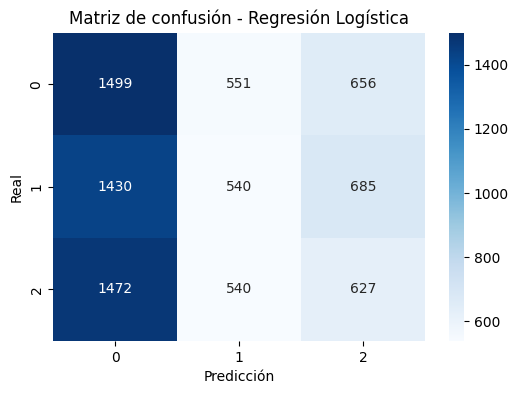

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

La matriz de confusión permite observar la distribución de aciertos y errores del modelo en cada clase. Se evidencia que el modelo presenta dificultades para diferenciar correctamente entre las clases, reforzando los resultados observados en el classification report.

##### CALCULO DE ERROR DE GENERALIZACION

In [33]:
print("REGRESION LOGISTICA")
print("Train accuracy:", accuracy_score(y_train, model_lr.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, y_pred_lr))

REGRESION LOGISTICA
Train accuracy: 0.3435625
Test accuracy: 0.33325


Posteriormente, se realizó una prueba adicional ajustando el parámetro de regularización del modelo de Regresión Logística, con el objetivo de mejorar su capacidad de generalización. Sin embargo, no se observaron mejoras significativas en el rendimiento, manteniéndose la accuracy en valores similares. Esto sugiere que la limitación no radica en la configuración del modelo, sino en la información contenida en las variables.

El modelo de **Regresión Logística** obtiene una **accuracy** de aproximadamente **0.34**, lo que indica un desempeño moderado en la clasificación de las distintas clases.
A partir del **classification report**, se observa que el modelo presenta un mejor rendimiento en la clase **“Blocked”**, mientras que su capacidad de predicción es menor en las clases **“Ignored”** y **“Logged”**, especialmente en esta última, donde el **recall** es más bajo.
En general, el modelo muestra un desempeño equilibrado pero limitado, lo que sugiere que podría no ser el más adecuado para capturar la complejidad del problema.

#### SEGUNDO MODELO — ARBOL DE DECISIONES

A continuacion, se entrena un modelo de Árbol de Decisión, el cual permite capturar relaciones no lineales entre las variables, a diferencia de la regresión logística.

En una primera prueba, el modelo de Árbol de Decisión presentaba signos de sobreajuste, obteniendo un rendimiento significativamente mayor en los datos de entrenamiento que en los de prueba.

Para mitigar este comportamiento, se ajustaron los hiperparámetros del modelo, limitando la profundidad del árbol y el número mínimo de muestras necesarias para realizar divisiones. Esto permite reducir la complejidad del modelo y mejorar su capacidad de generalización.

In [34]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    max_depth=5,                      #  añadido para reducir overfitting
    min_samples_split=10,             #  añadido para mejorar generalización
    random_state=42
)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

posteriormente evaluaremos el rendimiento del modelo utilizando las mismas métricas que en el caso anterior, con el fin de poder comparar los resultados.

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.34175
              precision    recall  f1-score   support

     Blocked       0.34      0.82      0.48      2706
     Ignored       0.36      0.08      0.13      2655
      Logged       0.34      0.11      0.17      2639

    accuracy                           0.34      8000
   macro avg       0.35      0.34      0.26      8000
weighted avg       0.35      0.34      0.26      8000



##### CALCULO DE ERROR DE GENERALIZACION

In [36]:
print("ARBOL DE DECISIONES")
print("Train accuracy:", accuracy_score(y_train, model_dt.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, y_pred_dt))

ARBOL DE DECISIONES
Train accuracy: 0.3528125
Test accuracy: 0.34175


⚠️ Nota: Dado que los resultados obtenidos son consistentes con los observados en el modelo de Regresión Logística, no se incluye la matriz de confusión para este modelo con el fin de evitar redundancia, ya que no aporta información adicional relevante.

El modelo de **Árbol de Decisión**, tras el ajuste de **hiperparámetros**, presenta una reducción significativa del **sobreajuste**, obteniendo valores de **accuracy** similares en entrenamiento y prueba.
Sin embargo, el rendimiento general se mantiene en torno a **0.34**, sin mejoras significativas respecto a versiones anteriores. Esto sugiere que la limitación no radica en la complejidad del modelo, sino en la **baja capacidad predictiva** de las variables disponibles, las cuales no permiten una correcta discriminación entre las clases.

#### TERCER MODELO — RANDOM FOREST

En una primera prueba, el modelo **Random Forest** presentaba signos de **sobreajuste**, con un rendimiento significativamente mayor en los datos de entrenamiento. Para corregir este comportamiento, se ajustaron sus **hiperparámetros**, limitando la profundidad de los árboles y aumentando el número de estimadores, con el objetivo de mejorar la **capacidad de generalización** del modelo.


In [37]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,      # 🔹 CAMBIO 1: más árboles → mejor estabilidad
    max_depth=10,          # 🔹 CAMBIO 2: limita profundidad → reduce overfitting
    min_samples_split=5,   # 🔹 CAMBIO 3: evita divisiones muy específicas
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

A continuación, se evalúa el rendimiento del modelo utilizando métricas como accuracy y classification report. Estas permiten analizar tanto la precisión global del modelo como su desempeño en cada una de las clases, facilitando la comparación con los modelos previamente entrenados

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.329125
              precision    recall  f1-score   support

     Blocked       0.34      0.47      0.40      2706
     Ignored       0.32      0.27      0.29      2655
      Logged       0.32      0.24      0.27      2639

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.32      8000
weighted avg       0.33      0.33      0.32      8000



#### CALCULO DE ERROR DE GENERALIZACION

In [39]:
print("RANDOM FOREST")
print("Train accuracy:", accuracy_score(y_train, model_rf.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, y_pred_rf))

RANDOM FOREST
Train accuracy: 0.7285
Test accuracy: 0.329125


#### IMPORTANCIA DE VARIABLES

El análisis de importancia de variables se muestra únicamente para el modelo Random Forest, ya que ofrece una visión más clara y confiable sobre qué variables influyen en las predicciones. En otros modelos, este tipo de análisis no resulta tan representativo o puede ser más difícil de interpretar, por lo que se opta por no incluirlo para evitar confusiones o información redundante.

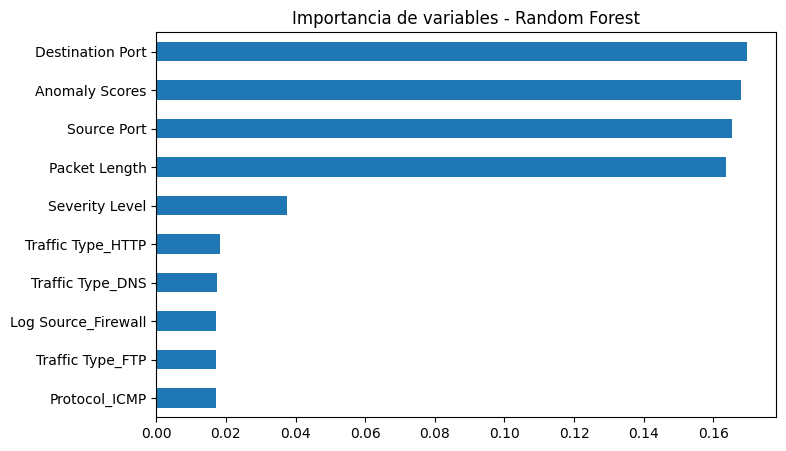

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model_rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh')
plt.title("Importancia de variables - Random Forest")
plt.gca().invert_yaxis()
plt.show()

El gráfico de importancia de variables permite identificar cuáles son las características que más influyen en las decisiones del modelo. Se observa que ninguna variable destaca de forma significativa sobre el resto, lo que refuerza la idea de que el dataset no contiene información suficientemente discriminante para realizar una clasificación efectiva.

⚠️ Nota: Dado que los resultados obtenidos son consistentes con los observados en el modelo de Regresión Logística, no se incluye la matriz de confusión para este modelo con el fin de evitar redundancia, ya que no aporta información adicional relevante.

A pesar del ajuste de hiperparámetros, el modelo **Random Forest** sigue mostrando una diferencia considerable entre el rendimiento en entrenamiento y prueba, lo que indica que continúa presentando **sobreajuste**.

Sin embargo, el rendimiento en el conjunto de prueba se mantiene en torno a **0.33**, sin mejoras significativas respecto a los modelos anteriores.

#### COMPARACIÓN ENTRE MODELOS

Al comparar los distintos modelos implementados, se observa que el **Árbol de Decisión** obtiene el mejor desempeño en términos de **accuracy**, alcanzando un valor aproximado de **0.342**, aunque las diferencias con respecto a los demás modelos no son muy grandes.

La Regresión Logística presenta un rendimiento muy similar, mientras que el modelo Random Forest obtiene un resultado ligeramente inferior y muestra una diferencia mayor entre entrenamiento y prueba.

Esto sugiere que, para este problema, utilizar modelos más complejos no aporta mejoras significativas, y que las variables disponibles no parecen tener suficiente capacidad para diferenciar claramente las distintas clases de la variable objetivo.

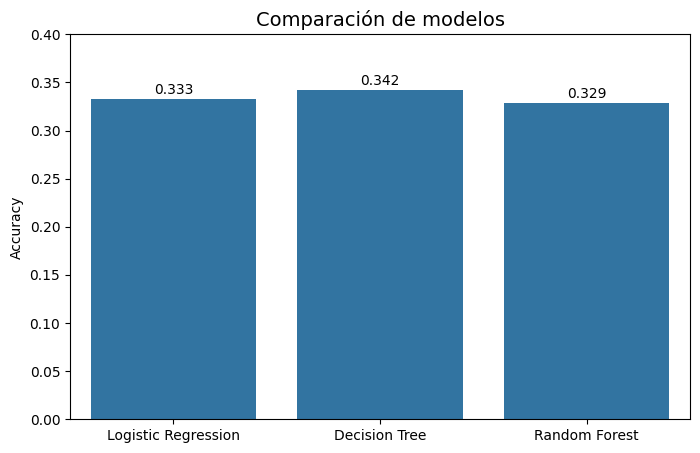

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [0.333, 0.342, 0.329]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)
plt.title("Comparación de modelos", fontsize=14)
plt.ylabel("Accuracy")
plt.ylim(0, 0.4)  # para que se vea mejor la diferencia

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()

## CONCLUSION FINAL DE PRACTICA

A partir del análisis realizado, se concluye que ninguno de los modelos implementados logra alcanzar un nivel de precisión elevado, obteniendo valores de **accuracy** en torno a **0.33–0.34**, cercanos al rendimiento esperado por una clasificación aleatoria en un problema con **tres clases balanceadas**.

Dado que el problema presenta **tres clases balanceadas**, un clasificador aleatorio tendría una **accuracy** esperada cercana a **0.33**, valor muy próximo al observado en los modelos entrenados.

Si bien se aplicaron distintas técnicas de preprocesamiento y ajustes de hiperparámetros, logrando reducir parcialmente el sobreajuste en modelos como **Árbol de Decisión** y realizando intentos de mejora en **Random Forest**, estas modificaciones no se traducen en un incremento significativo del rendimiento en el conjunto de prueba.

El análisis exploratorio permitió identificar que las variables del dataset no presentan una separación clara entre las distintas clases de la variable objetivo, lo que dificulta la capacidad de los modelos para encontrar patrones realmente discriminantes.

En consecuencia, se concluye que la principal limitación del problema no radica en la elección del modelo, sino en que las variables disponibles **no parecen aportar suficiente capacidad discriminante** para predecir de manera efectiva la variable **"Action Taken"**.